# AI Valuation — Short Thesis

**Tickers:** NVIDIA (NVDA) · Microsoft (MSFT) · Meta (META) · Palantir (PLTR) · C3.ai (AI)  
**Period:** 2020–2026 | **Data Source:** Yahoo Finance via yfinance | **Stack:** Python · Polars · Matplotlib

---

## Context

The AI boom since 2022 has pushed valuations to historically elevated levels. This analysis selectively examines whether current multiples are justified by fundamentals — and identifies specific short candidates within the sector.

**Thesis:** Not the entire AI sector is overvalued. NVDA and META are fundamentally sound. PLTR and C3.ai, however, trade at multiples that are not justified even under strong growth assumptions.

1. **Performance Analytics** — Who delivered, who didn't?
2. **Fundamental Valuation** — Valuation vs. Growth: where is the premium unjustified?
3. **Forward-Looking Indicators** — Does Smart Money (short interest) confirm our thesis?

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## Setup

Price data from `prices.parquet`, fundamentals from `fundamentals.parquet`, analyst data from `analysts.parquet` — all generated via `00_data_pipeline.ipynb`. All DataFrame operations use **Polars**.

In [15]:
prices = pl.read_parquet("/Users/raphaelzimmermann/tradingbot_v41/quant_analytics/01_market_microstructure/data/thesis/prices.parquet")

In [16]:
prices

date,ticker,close
datetime[ms],str,f64
2020-12-09 00:00:00,"""AI""",92.489998
2020-12-10 00:00:00,"""AI""",130.0
2020-12-11 00:00:00,"""AI""",119.580002
2020-12-14 00:00:00,"""AI""",102.360001
2020-12-15 00:00:00,"""AI""",102.0
…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005
2026-02-23 00:00:00,"""PLTR""",130.600006
2026-02-24 00:00:00,"""PLTR""",128.839996


In [17]:
AI_TICKERS = ["NVDA", "MSFT", "META", "PLTR", "AI"]


AI = prices.filter(pl.col("ticker").is_in(AI_TICKERS))
print(AI["ticker"].unique())
AI

shape: (5,)
Series: 'ticker' [str]
[
	"META"
	"MSFT"
	"PLTR"
	"NVDA"
	"AI"
]


date,ticker,close
datetime[ms],str,f64
2020-12-09 00:00:00,"""AI""",92.489998
2020-12-10 00:00:00,"""AI""",130.0
2020-12-11 00:00:00,"""AI""",119.580002
2020-12-14 00:00:00,"""AI""",102.360001
2020-12-15 00:00:00,"""AI""",102.0
…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005
2026-02-23 00:00:00,"""PLTR""",130.600006
2026-02-24 00:00:00,"""PLTR""",128.839996


## Layer 1 — Performance Analytics

Objective: Quantify the historical return and risk profile of AI sector equities.

Important: strong historical performance is **not** a counterargument to a short — it only shows how long a momentum trade can run. What matters is the ratio of return to risk (Sharpe Ratio) and the maximum drawdown.

- **Sharpe Ratio:** `(Ann. Return − RF) / Ann. Volatility` | RF = 3%
- **Max Drawdown:** Measures the worst peak-to-trough loss — a proxy for tail risk

In [18]:
AI = (
    AI
    .sort(["ticker", "date"])
    .with_columns([
        pl.col("close")
          .pct_change()
          .over("ticker")        
          .alias("daily_return")
    ])
    .drop_nulls()
)

AI.head(8)


date,ticker,close,daily_return
datetime[ms],str,f64,f64
2020-12-10 00:00:00,"""AI""",130.0,0.405557
2020-12-11 00:00:00,"""AI""",119.580002,-0.080154
2020-12-14 00:00:00,"""AI""",102.360001,-0.144004
2020-12-15 00:00:00,"""AI""",102.0,-0.003517
2020-12-16 00:00:00,"""AI""",113.690002,0.114608
2020-12-17 00:00:00,"""AI""",117.239998,0.031225
2020-12-18 00:00:00,"""AI""",137.589996,0.173576
2020-12-21 00:00:00,"""AI""",160.889999,0.169344


In [19]:
AI_cum = (
    AI
    .with_columns([
        (1 + pl.col("daily_return"))
          .cum_prod()
          .over("ticker")
          .alias("cum_return")
    ])
)
AI_cum

date,ticker,close,daily_return,cum_return
datetime[ms],str,f64,f64,f64
2020-12-10 00:00:00,"""AI""",130.0,0.405557,1.405557
2020-12-11 00:00:00,"""AI""",119.580002,-0.080154,1.292897
2020-12-14 00:00:00,"""AI""",102.360001,-0.144004,1.106714
2020-12-15 00:00:00,"""AI""",102.0,-0.003517,1.102822
2020-12-16 00:00:00,"""AI""",113.690002,0.114608,1.229214
…,…,…,…,…
2026-02-20 00:00:00,"""PLTR""",135.240005,0.002595,14.23579
2026-02-23 00:00:00,"""PLTR""",130.600006,-0.034309,13.747369
2026-02-24 00:00:00,"""PLTR""",128.839996,-0.013476,13.562105


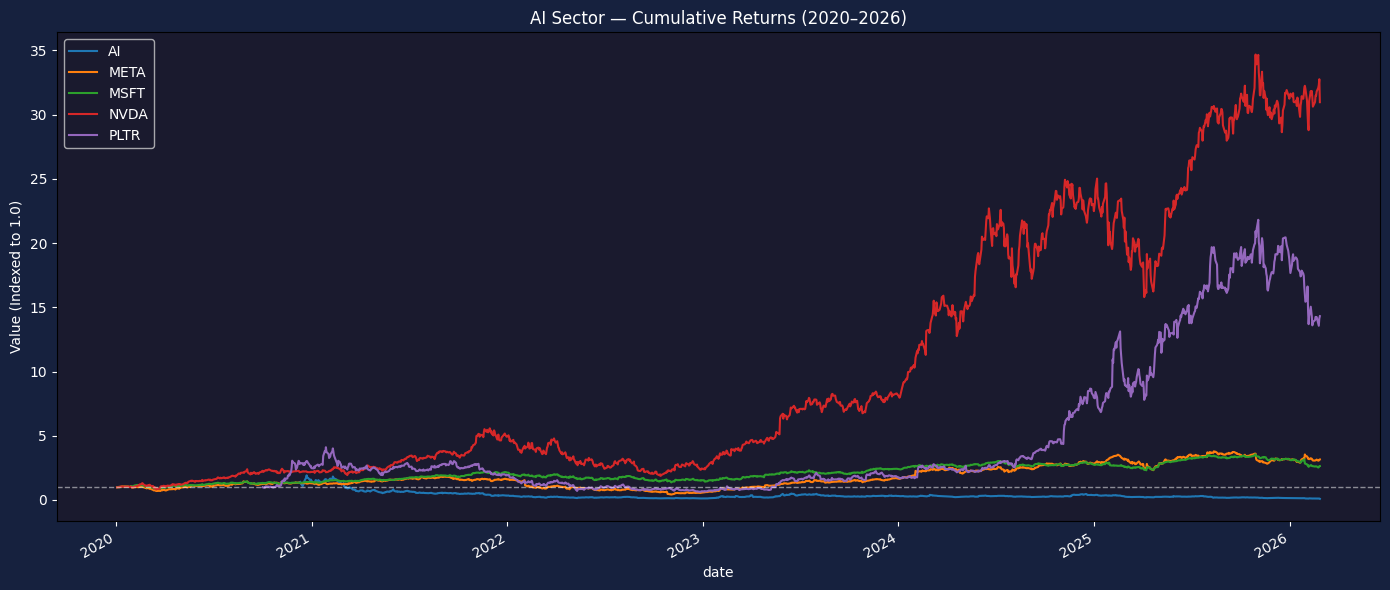

In [20]:
wide = (
    AI_cum
    .select(["date", "ticker", "cum_return"])
    .pivot(index="date", on="ticker", values="cum_return")
    .sort("date")
)

df_plot = wide.to_pandas().set_index("date")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

df_plot.plot(ax=ax)
ax.axhline(1.0, color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("AI Sector — Cumulative Returns (2020–2026)", color="white")
ax.set_ylabel("Value (Indexed to 1.0)", color="white")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.legend(loc="upper left", facecolor="#1a1a2e", labelcolor="white")
plt.tight_layout()
plt.show()

In [21]:
RF = 0.03
TRADING_DAYS = 252

metrics = (
    AI
    .group_by("ticker")
    .agg([
        # Annualized Return
        ((1 + pl.col("daily_return")).product() 
            ** (TRADING_DAYS / pl.col("daily_return").count()) - 1
        ).alias("ann_return"),

        # Annualized Volatility — deine Aufgabe: ergänze die Formel
        # Tipp: .std() und np.sqrt(TRADING_DAYS)
        (pl.col("daily_return").std() * np.sqrt(TRADING_DAYS)).alias("ann_volatility"),
    ])
    .with_columns([
        # Sharpe — deine Aufgabe
        ((pl.col("ann_return") - RF) / pl.col("ann_volatility")).alias("sharpe"),
    ])
    .sort("ticker")
)

metrics

ticker,ann_return,ann_volatility,sharpe
str,f64,f64,f64
"""AI""",-0.370083,0.830857,-0.481531
"""META""",0.206043,0.437289,0.402578
"""MSFT""",0.171576,0.297993,0.475097
"""NVDA""",0.75053,0.528336,1.363772
"""PLTR""",0.639093,0.704974,0.863993


In [22]:
max_dd = (
    AI_cum
    .with_columns([
        pl.col("cum_return")
          .cum_max()
          .over("ticker")
          .alias("rolling_max")
    ])
    .with_columns([
        ((pl.col("cum_return") - pl.col("rolling_max")) / pl.col("rolling_max"))
          .alias("drawdown")
    ])
    .group_by("ticker")
    .agg(pl.col("drawdown").min().alias("max_drawdown"))
)

max_dd


ticker,max_drawdown
str,f64
"""AI""",-0.952668
"""META""",-0.767361
"""MSFT""",-0.371485
"""NVDA""",-0.663351
"""PLTR""",-0.846154


In [23]:
join = max_dd.join(metrics, on="ticker").sort("ticker")
print(join)

shape: (5, 5)
┌────────┬──────────────┬────────────┬────────────────┬───────────┐
│ ticker ┆ max_drawdown ┆ ann_return ┆ ann_volatility ┆ sharpe    │
│ ---    ┆ ---          ┆ ---        ┆ ---            ┆ ---       │
│ str    ┆ f64          ┆ f64        ┆ f64            ┆ f64       │
╞════════╪══════════════╪════════════╪════════════════╪═══════════╡
│ AI     ┆ -0.952668    ┆ -0.370083  ┆ 0.830857       ┆ -0.481531 │
│ META   ┆ -0.767361    ┆ 0.206043   ┆ 0.437289       ┆ 0.402578  │
│ MSFT   ┆ -0.371485    ┆ 0.171576   ┆ 0.297993       ┆ 0.475097  │
│ NVDA   ┆ -0.663351    ┆ 0.75053    ┆ 0.528336       ┆ 1.363772  │
│ PLTR   ┆ -0.846154    ┆ 0.639093   ┆ 0.704974       ┆ 0.863993  │
└────────┴──────────────┴────────────┴────────────────┴───────────┘


In [24]:
print(
    join.with_columns([
        (pl.col("ann_return") * 100).round(1).alias("ann_return_%"),
        (pl.col("ann_volatility") * 100).round(1).alias("ann_vol_%"),
        pl.col("sharpe").round(2),
        (pl.col("max_drawdown") * 100).round(1).alias("max_dd_%"),
    ])
    .select(["ticker", "ann_return_%", "ann_vol_%", "sharpe", "max_dd_%"])
)


shape: (5, 5)
┌────────┬──────────────┬───────────┬────────┬──────────┐
│ ticker ┆ ann_return_% ┆ ann_vol_% ┆ sharpe ┆ max_dd_% │
│ ---    ┆ ---          ┆ ---       ┆ ---    ┆ ---      │
│ str    ┆ f64          ┆ f64       ┆ f64    ┆ f64      │
╞════════╪══════════════╪═══════════╪════════╪══════════╡
│ AI     ┆ -37.0        ┆ 83.1      ┆ -0.48  ┆ -95.3    │
│ META   ┆ 20.6         ┆ 43.7      ┆ 0.4    ┆ -76.7    │
│ MSFT   ┆ 17.2         ┆ 29.8      ┆ 0.48   ┆ -37.1    │
│ NVDA   ┆ 75.1         ┆ 52.8      ┆ 1.36   ┆ -66.3    │
│ PLTR   ┆ 63.9         ┆ 70.5      ┆ 0.86   ┆ -84.6    │
└────────┴──────────────┴───────────┴────────┴──────────┘


## Layer 2 — Fundamental Valuation

Objective: Are current valuations justified by company fundamentals?

Core question: **Valuation vs. Growth** — a high P/E is only justified if the company grows at a proportional rate. The classic tool for this is the **PEG Ratio** (`Forward P/E / Revenue Growth`). A PEG > 1 signals overvaluation relative to growth.

The scatter plot "Valuation vs. Growth" makes this tension visually explicit.

In [25]:
fundamentals = pl.read_parquet("/Users/raphaelzimmermann/tradingbot_v41/quant_analytics/01_market_microstructure/data/thesis/fundamentals.parquet")
ai_fund = fundamentals.filter(pl.col("ticker").is_in(AI_TICKERS))
print(ai_fund)

shape: (5, 10)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ticker ┆ market_cap ┆ pe_trailin ┆ pe_forwar ┆ … ┆ revenue_g ┆ free_cash ┆ gross_mar ┆ operating │
│ ---    ┆ ---        ┆ g          ┆ d         ┆   ┆ rowth     ┆ flow      ┆ gin       ┆ _margin   │
│ str    ┆ i64        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│        ┆            ┆ f64        ┆ f64       ┆   ┆ f64       ┆ i64       ┆ f64       ┆ f64       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NVDA   ┆ 4441738575 ┆ 37.21996   ┆ 17.09596  ┆ … ┆ 0.732     ┆ 581289984 ┆ 0.71068   ┆ 0.65024   │
│        ┆ 872        ┆            ┆           ┆   ┆           ┆ 00        ┆           ┆           │
│ MSFT   ┆ 2963958136 ┆ 24.95557   ┆ 21.164682 ┆ … ┆ 0.167     ┆ 536406261 ┆ 0.68586   ┆ 0.47094   │
│        ┆ 832        ┆            ┆           ┆   ┆           ┆ 76        ┆

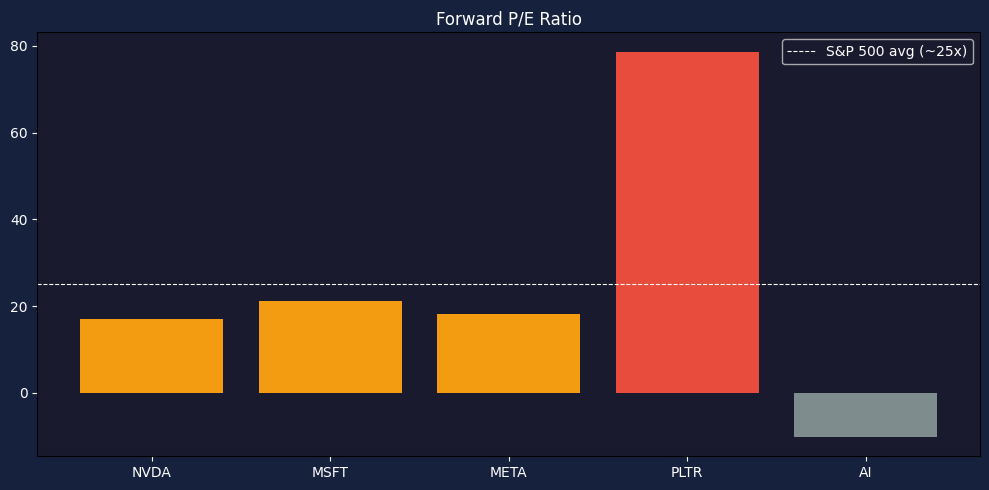

In [26]:
tickers_f  = ai_fund["ticker"].to_list()
pe_forward = ai_fund["pe_forward"].to_list()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

colors = ["#e74c3c" if pe and pe > 50 else "#f39c12" if pe and pe > 0 else "#7f8c8d"
          for pe in pe_forward]

ax.bar(tickers_f, pe_forward, color=colors)
ax.axhline(25, color="white", linewidth=0.8, linestyle="--", label="S&P 500 avg (~25x)")
ax.set_title("Forward P/E Ratio", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
plt.tight_layout()
plt.show()


## Layer 3 — Forward-Looking Indicators

Objective: Analyze market expectations and institutional investor positioning.

- **Analyst Consensus & Price Targets:** Shows the sell-side expected range (Low/Mean/High)
- **Short Interest:** % of float sold short — the most important signal in this layer. A high value indicates institutional investors (hedge funds etc.) are already positioned short.
  > *Risk: High short interest increases squeeze potential on positive surprises.*

In [27]:
analysts = pl.read_parquet("/Users/raphaelzimmermann/tradingbot_v41/quant_analytics/01_market_microstructure/data/thesis/analysts.parquet")
ai_ana = analysts.filter(pl.col("ticker").is_in(AI_TICKERS))
print(ai_ana)

shape: (5, 7)
┌────────┬────────────────┬─────────────┬─────────────┬────────────┬──────────────┬────────────────┐
│ ticker ┆ recommendation ┆ target_mean ┆ target_high ┆ target_low ┆ num_analysts ┆ short_interest │
│ ---    ┆ ---            ┆ ---         ┆ ---         ┆ ---        ┆ ---          ┆ ---            │
│ str    ┆ str            ┆ f64         ┆ f64         ┆ f64        ┆ i64          ┆ f64            │
╞════════╪════════════════╪═════════════╪═════════════╪════════════╪══════════════╪════════════════╡
│ NVDA   ┆ strong_buy     ┆ 263.81775   ┆ 380.0       ┆ 140.0      ┆ 58           ┆ 0.0109         │
│ MSFT   ┆ strong_buy     ┆ 595.99567   ┆ 730.0       ┆ 392.0      ┆ 53           ┆ 0.0076         │
│ META   ┆ strong_buy     ┆ 863.19934   ┆ 1144.0      ┆ 700.0      ┆ 59           ┆ 0.0124         │
│ PLTR   ┆ buy            ┆ 184.48808   ┆ 260.0       ┆ 70.0       ┆ 26           ┆ 0.0235         │
│ AI     ┆ hold           ┆ 9.45455     ┆ 17.0        ┆ 6.0        ┆ 11      

In [28]:
current_prices = (
    prices.filter(pl.col("ticker").is_in(AI_TICKERS))
    .sort("date")
    .group_by("ticker")
    .agg(pl.col("close").last().alias("current_price"))
)

ai_full = ai_ana.join(current_prices, on="ticker").sort("ticker")
print(ai_full.select(["ticker", "current_price", "target_low", "target_mean", "target_high", "recommendation"]))

shape: (5, 6)
┌────────┬───────────────┬────────────┬─────────────┬─────────────┬────────────────┐
│ ticker ┆ current_price ┆ target_low ┆ target_mean ┆ target_high ┆ recommendation │
│ ---    ┆ ---           ┆ ---        ┆ ---         ┆ ---         ┆ ---            │
│ str    ┆ f64           ┆ f64        ┆ f64         ┆ f64         ┆ str            │
╞════════╪═══════════════╪════════════╪═════════════╪═════════════╪════════════════╡
│ AI     ┆ 8.4           ┆ 6.0        ┆ 9.45455     ┆ 17.0        ┆ hold           │
│ META   ┆ 657.01001     ┆ 700.0      ┆ 863.19934   ┆ 1144.0      ┆ strong_buy     │
│ MSFT   ┆ 401.720001    ┆ 392.0      ┆ 595.99567   ┆ 730.0       ┆ strong_buy     │
│ NVDA   ┆ 184.889999    ┆ 140.0      ┆ 263.81775   ┆ 380.0       ┆ strong_buy     │
│ PLTR   ┆ 135.940002    ┆ 70.0       ┆ 184.48808   ┆ 260.0       ┆ buy            │
└────────┴───────────────┴────────────┴─────────────┴─────────────┴────────────────┘


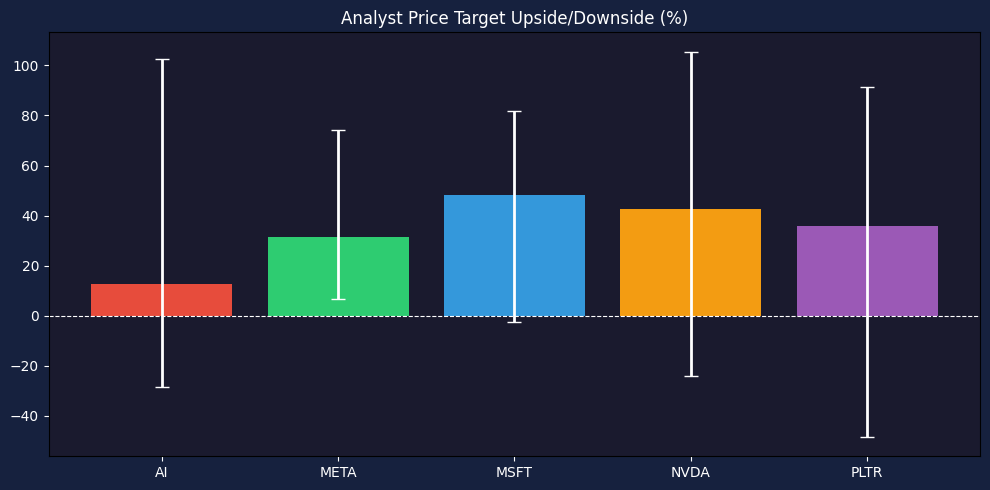

In [29]:
tickers_s   = ai_full["ticker"].to_list()
current     = ai_full["current_price"].to_list()
t_mean      = ai_full["target_mean"].to_list()
t_high      = ai_full["target_high"].to_list()
t_low       = ai_full["target_low"].to_list()

upside_mean = [(m - c) / c * 100 for m, c in zip(t_mean, current)]
upside_high = [(h - c) / c * 100 for h, c in zip(t_high, current)]
upside_low  = [(l - c) / c * 100 for l, c in zip(t_low, current)]

errors_below = [upside_mean[i] - upside_low[i]  for i in range(len(tickers_s))]
errors_above = [upside_high[i] - upside_mean[i] for i in range(len(tickers_s))]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

colors = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6"]
ax.bar(tickers_s, upside_mean, color=colors, zorder=2)
ax.errorbar(tickers_s, upside_mean,
            yerr=[errors_below, errors_above],
            fmt="none", color="white", capsize=5, linewidth=2)

ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
ax.set_title("Analyst Price Target Upside/Downside (%)", color="white")
ax.tick_params(colors="white")
ax.set_xticks(range(len(tickers_s)))
ax.set_xticklabels(tickers_s, color="white")
plt.tight_layout()
plt.show()

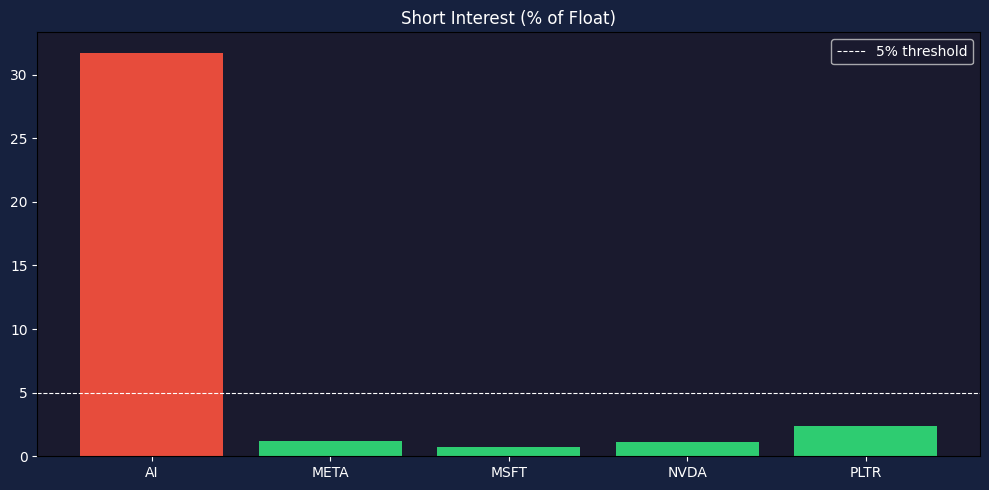

In [30]:
short_interest = [(s * 100 if s is not None else 0) for s in ai_full["short_interest"].to_list()]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#16213e")
ax.set_facecolor("#1a1a2e")

bar_colors = ["#e74c3c" if s > 10 else "#f39c12" if s > 3 else "#2ecc71"
              for s in short_interest]
ax.bar(tickers_s, short_interest, color=bar_colors)
ax.axhline(5, color="white", linewidth=0.8, linestyle="--", label="5% threshold")
ax.set_title("Short Interest (% of Float)", color="white")
ax.tick_params(colors="white")
ax.set_xticks(range(len(tickers_s)))
ax.set_xticklabels(tickers_s, color="white")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
plt.tight_layout()
plt.show()

# Investment Summary — AI Valuation Short

## Thesis Overview

The AI sector is not uniformly overvalued — it is bifurcated. NVIDIA, Microsoft, and Meta are generating real cash flows that partially justify premium multiples. The short thesis applies specifically to companies where valuation is entirely disconnected from current and near-term fundamentals: Palantir and C3.ai.

**Our position:** No short on NVDA, MSFT, or META. Selective short on PLTR (valuation) and C3.ai (broken business model). C3.ai is the cleaner short; PLTR is higher-risk due to accelerating commercial growth.

---

## NVIDIA — Not a Short

NVIDIA trades at approximately 17x forward earnings against 73% revenue growth — a premium that is earned. Hyperscaler capex commitments of $530bn+ in 2026 make NVDA's near-term revenue visibility the strongest of any company in this screen. Sharpe ratio of 1.37 over the observed period reflects genuine alpha generation, not narrative speculation.

## Palantir — Valuation Short, Not Fundamental Short

Palantir reported Q4 2025 revenue of $1.41bn (+70% YoY) and guided 2026 revenue to $7.18–7.20bn (61% growth), crushing consensus. This is not a broken business. However, at 75x forward P/E — a 4.6x premium over NVIDIA despite operating in a more competitive and commoditizable software layer — the valuation leaves no margin for error. The bear case is not that AIP fails: it is that any deceleration in US commercial growth (currently 137% YoY) compresses the multiple violently. Michael Burry's public bearish flag in February 2026 and a 20%+ drawdown from January highs despite strong earnings confirm that sentiment can reverse faster than fundamentals. 23 out of 25 analysts rate PLTR Hold or Sell. The stock is priced for perfection at a moment when AI software competition from Microsoft, Google, and Amazon is intensifying.

> **Catalyst to watch:** Q1 2026 earnings (expected May 2026). If US commercial revenue growth decelerates below 100% for the first time since AIP launch, expect multiple compression of 30–40%. That is the trigger.

## C3.ai — Thesis Confirmed. This Is a Broken Business.

C3.ai is no longer a short thesis — it is a post-mortem. In Q3 FY2026, the company reported revenue of $53.3M, a 46% year-over-year decline, missing its own guidance of $72–80M by a third. Full-year FY2026 guidance was cut from $447–484M to $247–251M — nearly halved. A 26% workforce reduction followed. The new CEO acknowledged the company was "burning too much money." Bank of America cut its price target to $10 with an Underperform rating. The stock is down 36% year-to-date in 2026 alone, trading near all-time lows around $8.

The structural failure is not cyclical. C3.ai built an enterprise AI platform during the hype cycle of 2022–2023, priced it at a premium, failed to convert pilots into recurring contracts, and is now watching hyperscalers (AWS, Azure, Google Cloud) commoditize the exact functionality it charges for. With $622M cash remaining and Q4 guided at $48–52M, the runway is finite unless restructuring delivers a commercial inflection — and there is no evidence yet that it will.

> **Residual risk:** Short interest now stands at approximately 39% of float. A short squeeze remains possible on any positive catalyst. The easy money on the short side has likely been made; new entries require a clear stop-loss above the $12–13 resistance level.

---

## Portfolio Summary

| Ticker | Thesis | Rating | Key Catalyst (2026) |
|--------|--------|--------|---------------------|
| AI.PA | Long | Conviction Buy | ENNOH launch, EU Strategy revision Q2 |
| LIN | Long | Conviction Buy | Green steel FIDs, US hydrogen buildout |
| NEL.OL | Long | Speculative Buy | Order intake recovery, Herøya plant FID |
| NVDA | Neutral | No position | Hyperscaler capex remains elevated |
| MSFT | Neutral | No position | Consistent execution, fair multiple |
| META | Neutral | No position | Ad revenue + AI efficiency story intact |
| PLTR | Short | Valuation Short | Q1 2026 US commercial growth deceleration |
| AI | Short | Strong Short | Continued revenue decline confirmed Q3 FY26 |

---

*Research compiled March 2026. All investment theses represent analytical viewpoints for educational and portfolio demonstration purposes only.*